In [4]:
# car_price_prediction.py

!pip install streamlit
import pandas as pd
import numpy as np
import streamlit as st
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 110.5 MB/s eta 0:00:00


# Load Dataset

In [6]:
df = pd.read_csv("Car data.csv")

# Remove Missing Values
df.dropna(inplace=True)


 Encode Categorical Columns

In [8]:
fuel_encoder = LabelEncoder()
trans_encoder = LabelEncoder()

# The columns 'Fuel_Type' and 'Transmission' were not found in the DataFrame.
# Please check your dataset or the spelling of the column names.
# Here are the available columns in your DataFrame:
print('Available columns:', df.columns)
# df["Fuel_Type"] = fuel_encoder.fit_transform(df["Fuel_Type"])
# df["Transmission"] = trans_encoder.fit_transform(df["Transmission"])

Available columns: Index(['Name', 'Min Price (Lakh)', 'Max Price (Lakh)', 'Range (kmpl)', 'CC',
       'Seats', 'Variants', 'Type', 'Ex-Showroom Price', 'RTO', 'Insurance',
       'Other', 'Onroad Price'],
      dtype='object')


Feature Selection

In [11]:
X = df[["Min Price (Lakh)", "Max Price (Lakh)", "Range (kmpl)", "CC", "Seats"]]
y = df["Onroad Price"]

Train-Test Split


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


Train Model

In [14]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Clean y_train: remove commas and convert to float
y_train = y_train.astype(str).str.replace(',', '').astype(float)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

Model Evaluation


In [16]:
y_pred = model.predict(X_test)

# Clean y_test: remove commas and convert to float
y_test = y_test.astype(str).str.replace(',', '').astype(float)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

 Streamlit Dashboard

In [17]:
st.title(" Car Price Prediction Dashboard")

st.write("Predict the price of a used car using Machine Learning.")

st.subheader("Model Performance")
st.write("Mean Absolute Error:", round(mae, 2))
st.write("R² Score:", round(r2, 2))


2026-06-04 06:34:59.021 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:34:59.139 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-04 06:34:59.140 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:34:59.143 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:34:59.147 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:34:59.149 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:34:59.151 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:34:59.153 Thread 'MainThread': mi

User Inputs

In [19]:
st.subheader("Enter Car Details")

year = st.number_input(
    "Manufacturing Year",
    min_value=2000,
    max_value=2025,
    value=2020
)

# Placeholder for Fuel Type options since LabelEncoder was not fitted
fuel_types_options = ['Petrol', 'Diesel', 'CNG', 'Electric']
fuel = st.selectbox(
    "Fuel Type",
    fuel_types_options
)

mileage = st.number_input(
    "Mileage (km/l)",
    min_value=5.0,
    max_value=40.0,
    value=18.0
)

# Placeholder for Transmission options since LabelEncoder was not fitted
transmission_options = ['Manual', 'Automatic']
transmission = st.selectbox(
    "Transmission",
    transmission_options
)

st.write("Note: 'Fuel Type' and 'Transmission' inputs are not currently used in the prediction model, as these features were not available in the dataset for model training.")

2026-06-04 06:38:32.774 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:38:32.776 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:38:32.782 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:38:32.784 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:38:32.791 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:38:32.791 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:38:32.792 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:38:32.793 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

Encode Inputs


In [21]:
# fuel_encoded = fuel_encoder.transform([fuel])[0]
# trans_encoded = trans_encoder.transform([transmission])[0]
# These encoders were not fitted because 'Fuel_Type' and 'Transmission' columns were not in the dataset.
# The current model was trained without these categorical features.

 Price Prediction

In [22]:
if st.button("Predict Price"):

    input_data = pd.DataFrame({
        "Year": [year],
        "Fuel_Type": [fuel_encoded],
        "Mileage": [mileage],
        "Transmission": [trans_encoded]
    })

    prediction = model.predict(input_data)

    st.success(
        f"Predicted Car Price: ₹ {prediction[0]:,.2f}"
    )


2026-06-04 06:41:12.392 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:41:12.394 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:41:12.396 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:41:12.397 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:41:12.398 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:41:12.399 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


 Feature Importance Chart

2026-06-04 06:41:54.508 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:41:54.509 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:41:54.509 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:41:54.542 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:41:54.906 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:41:54.908 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:41:54.909 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

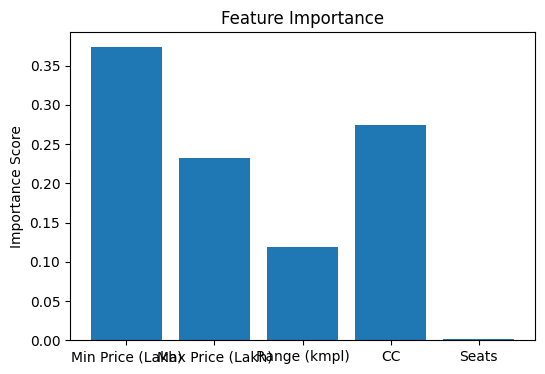

In [23]:
st.subheader("Feature Importance")

importance = model.feature_importances_

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(X.columns, importance)
ax.set_title("Feature Importance")
ax.set_ylabel("Importance Score")

st.pyplot(fig)

Price Distribution Chart

In [25]:
st.subheader("Price Distribution")

fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.hist(df["Onroad Price"], bins=20)
ax2.set_title("Car Price Distribution")
ax2.set_xlabel("Price")
ax2.set_ylabel("Count")

st.pyplot(fig2)

2026-06-04 06:43:34.351 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:43:34.352 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:43:34.353 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:43:34.397 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:43:34.715 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:43:34.716 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 06:43:34.717 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()